In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [2]:
df = pd.read_csv('SuperMarket Analysis.csv')

### EDA

In [3]:
df.sample(5)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
348,531-80-1784,Alex,Yangon,Normal,Male,Electronic accessories,26.02,7,9.1070,191.2470,3/28/2019,5:38:00 PM,Cash,182.14,4.761905,9.1070,5.1
445,390-80-5128,Cairo,Mandalay,Member,Female,Health and beauty,19.15,1,0.9575,20.1075,1/28/2019,5:58:00 PM,Credit card,19.15,4.761905,0.9575,9.5
344,150-89-8043,Alex,Yangon,Normal,Male,Sports and travel,44.65,3,6.6975,140.6475,2/14/2019,3:04:00 PM,Cash,133.95,4.761905,6.6975,6.2
255,110-48-7033,Cairo,Mandalay,Member,Male,Fashion accessories,32.62,4,6.5240,137.0040,1/29/2019,2:12:00 PM,Cash,130.48,4.761905,6.5240,9.0
459,729-46-7422,Giza,Naypyitaw,Normal,Male,Food and beverages,35.89,1,1.7945,37.6845,2/23/2019,4:52:00 PM,Credit card,35.89,4.761905,1.7945,7.9


In [4]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [5]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [7]:
df.nunique()

Invoice ID                 1000
Branch                        3
City                          3
Customer type                 2
Gender                        2
Product line                  6
Unit price                  943
Quantity                     10
Tax 5%                      990
Sales                       990
Date                         89
Time                        506
Payment                       3
cogs                        990
gross margin percentage       1
gross income                990
Rating                       61
dtype: int64

In [111]:
df.columns[df.isna().sum() > 0]

Index([], dtype='object')

In [9]:
df.dtypes

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

### Column standardization

In [10]:
df.columns = [col.replace(' ', '_').lower() for col in df.columns]

In [11]:
df['revenue']=df['unit_price']*df['quantity']

In [12]:
df['date_time']=pd.to_datetime(df['date'] + ' ' + df['time'], format='%m/%d/%Y %I:%M:%S %p')
df['date_time'].dtype

dtype('<M8[ns]')

In [13]:
df.date_time

0     2019-01-05 13:08:00
1     2019-03-08 10:29:00
2     2019-03-03 13:23:00
3     2019-01-27 20:33:00
4     2019-02-08 10:37:00
              ...        
995   2019-01-29 13:46:00
996   2019-03-02 17:16:00
997   2019-02-09 13:22:00
998   2019-02-22 15:33:00
999   2019-02-18 13:28:00
Name: date_time, Length: 1000, dtype: datetime64[ns]

### Questions

Which of the three branches generated the highest total revenue, and what was their average transaction value?

Does purchasing behavior differ by gender, and which product line is the most popular (by total quantity sold) among female customers versus male customers?

What is the busiest time of day for the supermarket based on the total number of transactions and total revenue?

Do 'Member' tier customers spend more on average than 'Normal' tier customers, and do their preferred payment methods differ?

Which product provided the supermarket with the most sales?

Which location of the supermarket provided the highest income?

Which day of the month, year, and week were the market sales the highest?

Is there a relationship between the product line and the average customer satisfaction rating?

#### Pandas

##### Which of the three branches generated the highest total revenue, and what was their average transaction value?

In [119]:
result=df.groupby('branch').agg(
    total_revenue=('revenue','sum'),
    average_transaction=('revenue','mean')
).sort_values(by='total_revenue',ascending=False)

In [120]:
result.sort_values(by='total_revenue',ascending=False).head(1)

,total_revenue,average_transaction
branch,,
Giza,105303.53,321.047348


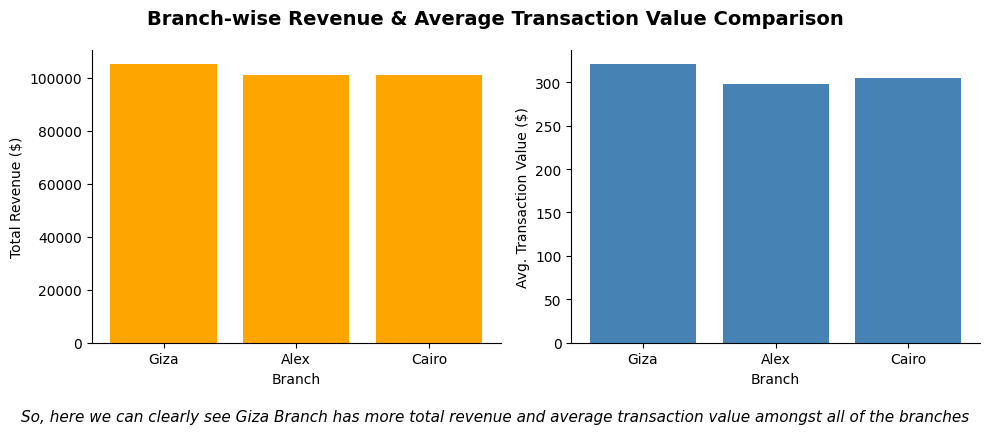

In [16]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.bar(result.index,result['total_revenue'],color='orange')
plt.xlabel("Branch")
plt.ylabel("Total Revenue ($)")

ax1=plt.gca()
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)


plt.subplot(1,2,2)

plt.bar(result.index,result['average_transaction'],color='steelblue')
plt.xlabel("Branch")
plt.ylabel("Avg. Transaction Value ($)")

ax2=plt.gca()
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)



plt.figtext(0.5, -0.05,
            'So, here we can clearly see Giza Branch has more total revenue '
            'and average transaction value amongst all of the branches',
            ha='center', fontsize=11, fontstyle='italic', color='black')

plt.suptitle("Branch-wise Revenue & Average Transaction Value Comparison", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

##### Does purchasing behavior differ by gender, and which product line is the most popular (by total quantity sold) among female customers versus male customers?


In [17]:
df.groupby(['gender','product_line'])['quantity'].sum()

gender  product_line          
Female  Electronic accessories    548
        Fashion accessories       586
        Food and beverages        568
        Health and beauty         425
        Home and lifestyle        561
        Sports and travel         600
Male    Electronic accessories    423
        Fashion accessories       316
        Food and beverages        384
        Health and beauty         429
        Home and lifestyle        350
        Sports and travel         320
Name: quantity, dtype: int64

Most popular Product line By Total Quantity of Male

In [18]:
mal_data=df[df['gender']=='Male'].groupby('product_line')['quantity'].sum().sort_values(ascending=False)

In [19]:
df[df['gender']=='Male'].groupby('product_line')['quantity'].sum().sort_values(ascending=False).head(1)

product_line
Health and beauty    429
Name: quantity, dtype: int64

Most popular Product line By Total Quantity of Female

In [20]:
fem_data=df[df['gender']=='Female'].groupby('product_line')['quantity'].sum().sort_values(ascending=False)

In [21]:
df[df['gender']=='Female'].groupby('product_line')['quantity'].sum().sort_values(ascending=False).head(1)

product_line
Sports and travel    600
Name: quantity, dtype: int64

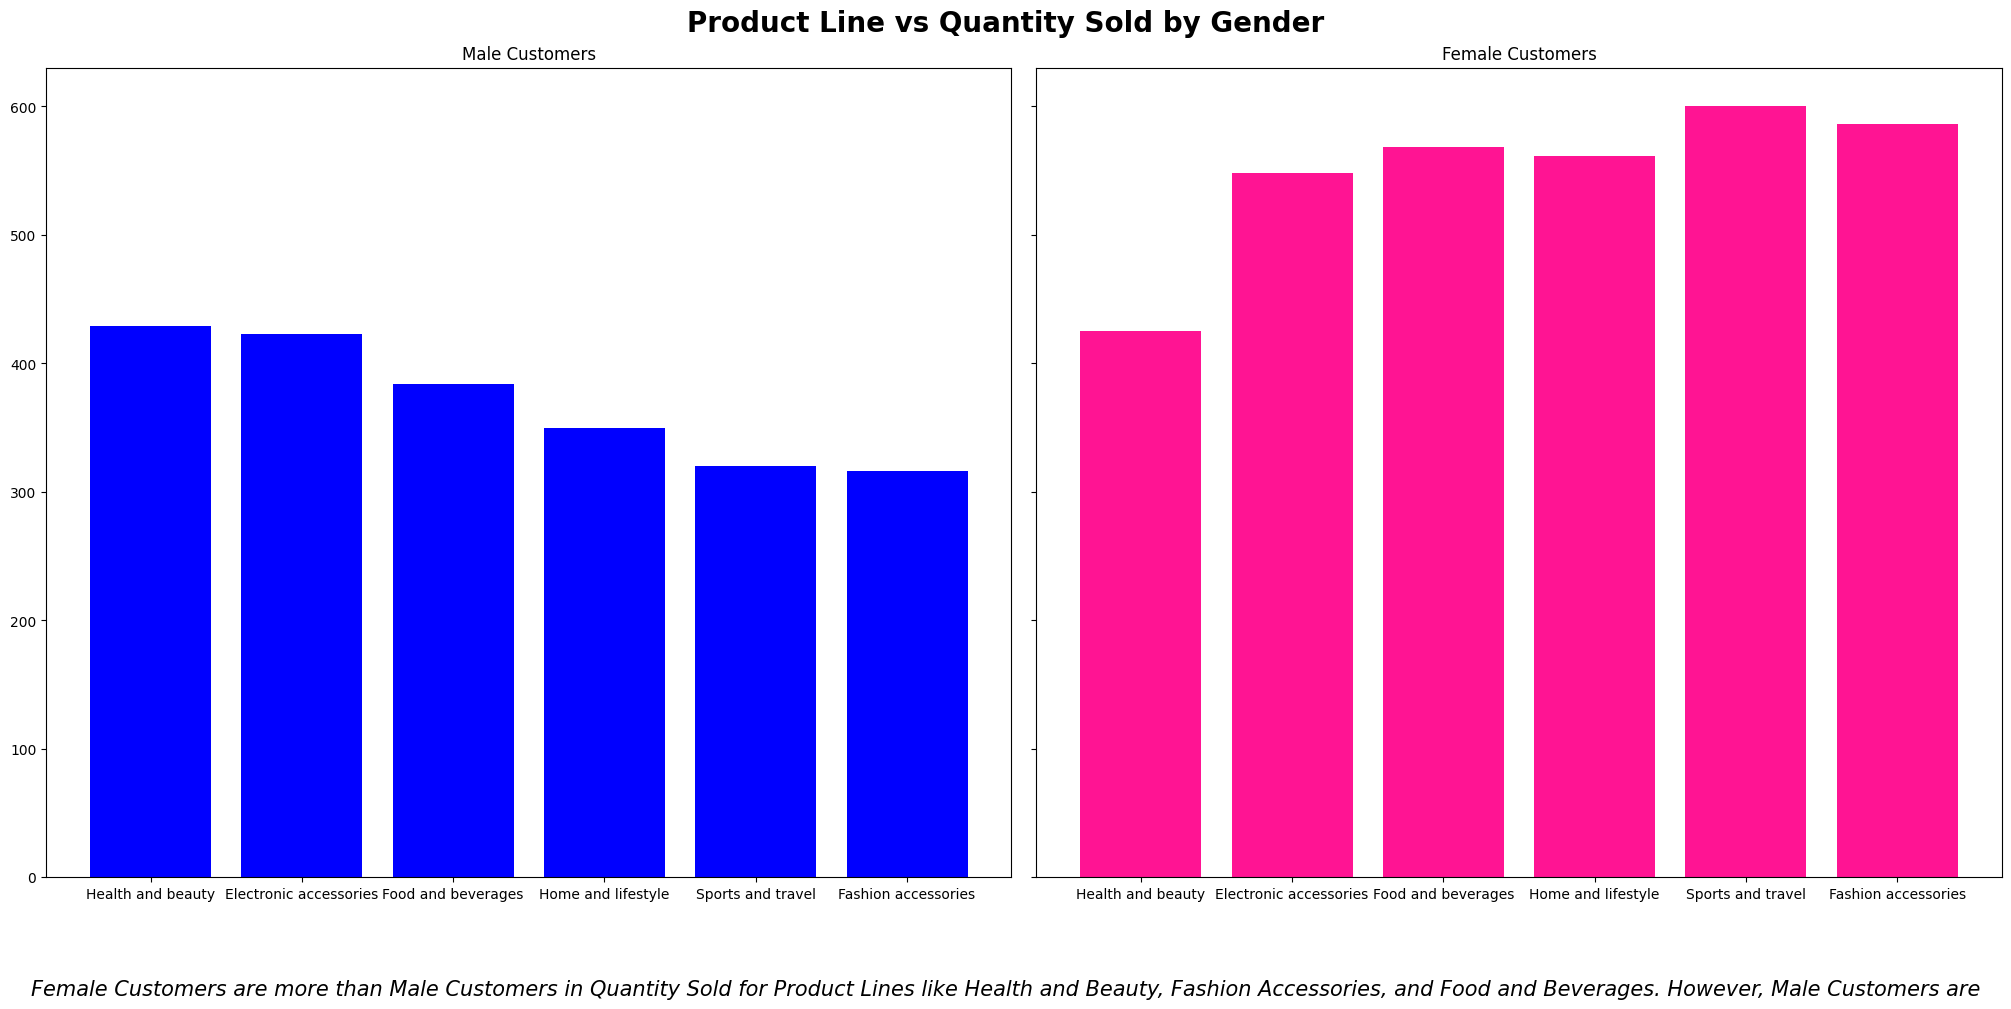

In [22]:
fig,ax=plt.subplots(1,2,figsize=(20,9), constrained_layout=True,sharey=True,sharex=True)


ax[0].bar(mal_data.index,mal_data,color='blue')
ax[0].set_title('Male Customers')


ax[1].bar(fem_data.index,fem_data,color='deeppink')
ax[1].set_title('Female Customers')

fig.suptitle('Product Line vs Quantity Sold by Gender',fontsize=20,fontweight='bold')


fig.text(0.5, -0.1, '''Female Customers are more than Male Customers in Quantity Sold for Product Lines like Health and Beauty, Fashion Accessories, and Food and Beverages. However, Male Customers are''', 
         ha='center', fontsize=15,
         fontstyle= 'italic', color='Black')

plt.show()

What is the busiest time of day for the supermarket based on the total number of transactions and total revenue?

In [23]:
result=df.groupby(df.date_time.dt.hour).agg(total_transaction=('invoice_id','count'),
                                     total_revenue = ('revenue','sum'))

In [24]:
result.sort_values(by=['total_revenue','total_transaction'],ascending=False).head(1)

,total_transaction,total_revenue
date_time,,
19,113,37809.06


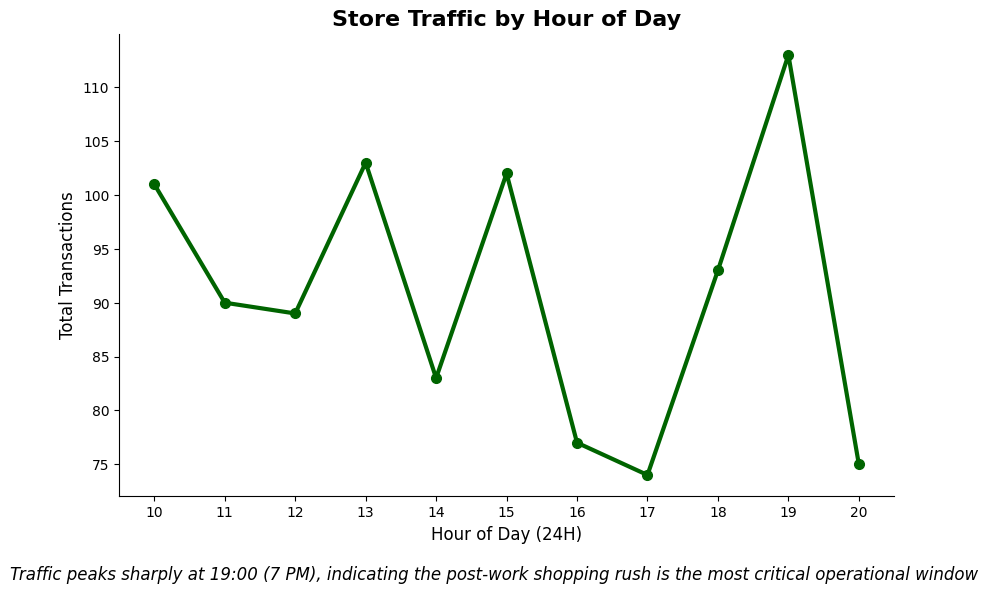

In [25]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')

ax.plot(result.index, result.total_transaction, marker='o', color='darkgreen', linewidth=3, markersize=7)

plt.title('Store Traffic by Hour of Day', fontsize=16, fontweight='bold', color='black')
plt.xlabel('Hour of Day (24H)', fontsize=12, color='black')
plt.ylabel('Total Transactions', fontsize=12, color='black')
plt.xticks(result.index)
ax.tick_params(colors='black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

insight = "Traffic peaks sharply at 19:00 (7 PM), indicating the post-work shopping rush is the most critical operational window"
plt.figtext(0.5, -0.03, insight, ha="center", fontsize=12, fontstyle="italic", color="black")

plt.show()

Do 'Member' tier customers spend more on average than 'Normal' tier customers, and do their preferred payment methods differ?

In [26]:
result=df.groupby(['customer_type','payment']).agg(
    total_transactions = ('invoice_id','count'),
    total_spent = ('revenue','sum')
)

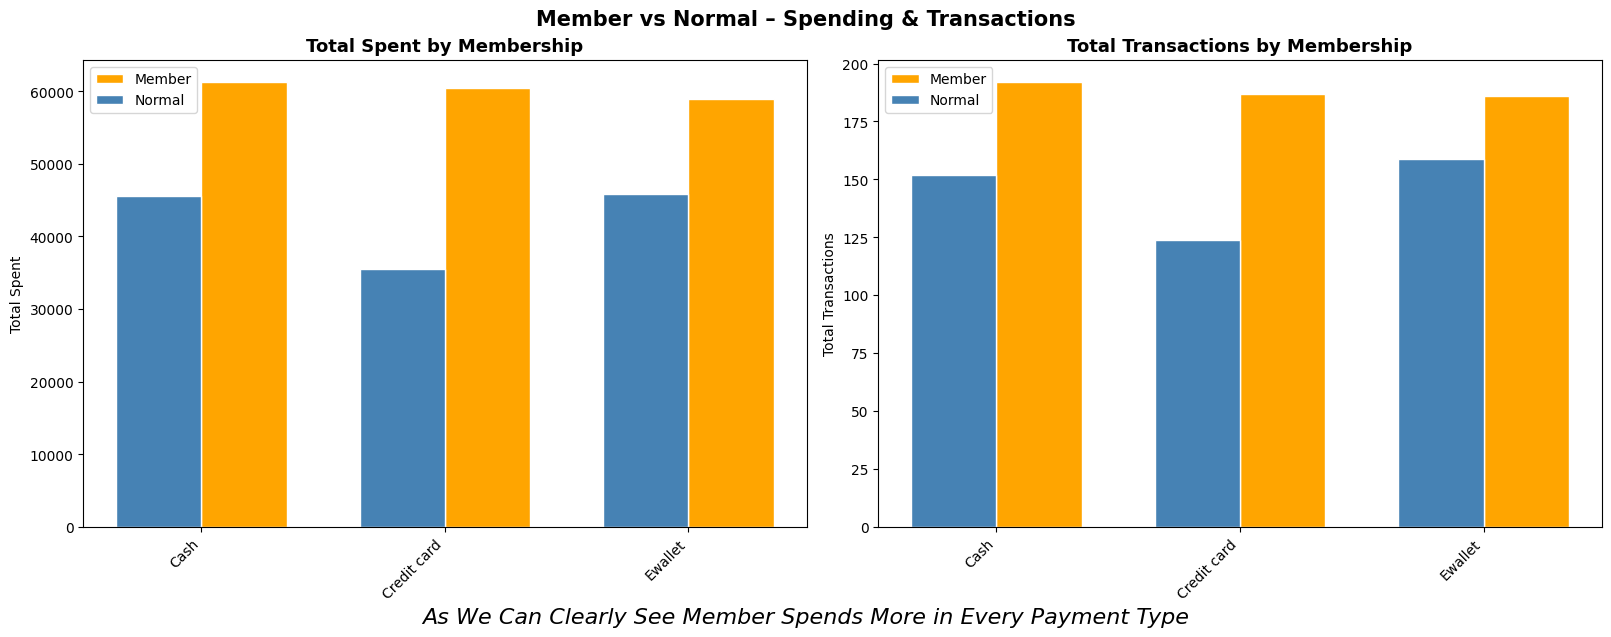

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

x = np.arange(len(result['total_spent']['Member']))
bar_width = 0.35

ax1.bar(x + bar_width/2, result['total_spent']['Member'], width=bar_width,color='orange', label='Member', edgecolor='white')
ax1.bar(x - bar_width/2, result['total_spent']['Normal'], width=bar_width,color='steelblue', label='Normal', edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels(result['total_spent']['Member'].index, rotation=45, ha='right')
ax1.set_title('Total Spent by Membership', fontsize=13, fontweight='bold')
ax1.set_ylabel('Total Spent')
ax1.legend(loc='upper left')




ax2.bar(x + bar_width/2, result['total_transactions']['Member'], width=bar_width,color='orange', label='Member', edgecolor='white')
ax2.bar(x - bar_width/2, result['total_transactions']['Normal'], width=bar_width,color='steelblue', label='Normal', edgecolor='white')

ax2.set_xticks(x)
ax2.set_xticklabels(result['total_transactions']['Member'].index, rotation=45, ha='right')
ax2.set_title('Total Transactions by Membership', fontsize=13, fontweight='bold')
ax2.set_ylabel('Total Transactions')
ax2.legend(loc='upper left')



fig.suptitle('Member vs Normal – Spending & Transactions', fontsize=15, fontweight='bold')


insight = "As We Can Clearly See Member Spends More in Every Payment Type"
plt.figtext(0.5, -0.03, insight, ha="center", fontsize=16, fontstyle="italic", color="black")


plt.show()   

Which product provided the supermarket with the most sales?

In [28]:
result=df.groupby('product_line')['sales'].sum()

In [29]:
result.sort_values(ascending=False).head(1)

product_line
Food and beverages    56144.844
Name: sales, dtype: float64

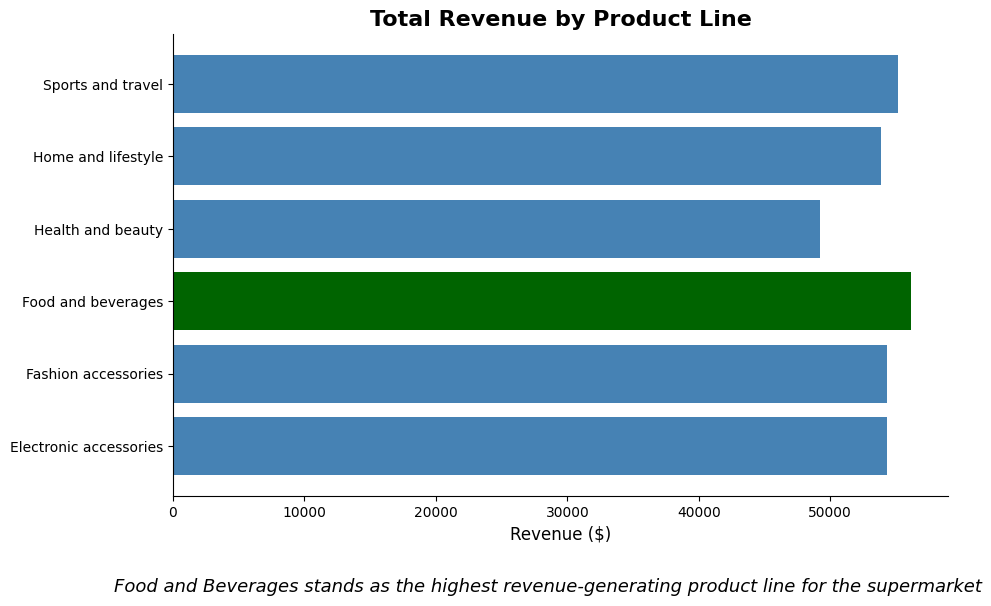

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

plt.barh(result.index,result,color='steelblue')
plt.barh(result.sort_values(ascending=False).head(1).index,result.max(),color='darkgreen')



plt.title('Total Revenue by Product Line', fontsize=16, fontweight='bold', color='black')
plt.xlabel('Revenue ($)', fontsize=12, color='black')
ax.tick_params(colors='black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

insight= "Food and Beverages stands as the highest revenue-generating product line for the supermarket"
plt.figtext(0.5, -0.05, insight, ha="center", fontsize=13, fontstyle="italic")

plt.show()

Which location of the supermarket provided the highest income?

In [31]:
result=df.groupby('city').agg(
    Gross_income_Per_City = ('gross_income','sum')
).sort_values(by='Gross_income_Per_City',ascending=False)

In [32]:
result.head(1)

,Gross_income_Per_City
city,
Naypyitaw,5265.1765


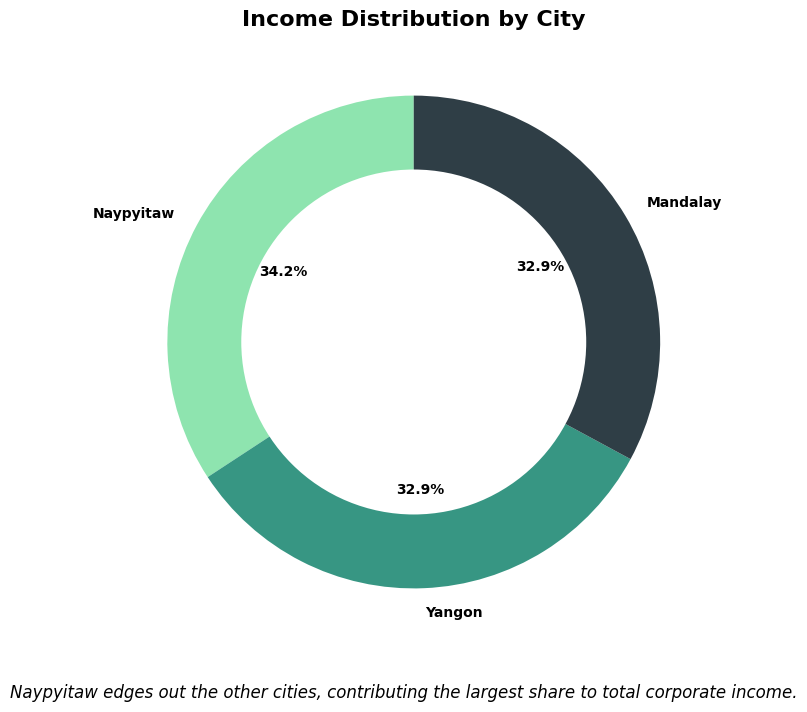

In [33]:
fig, ax = plt.subplots(figsize=(8, 8))

colors = ['#8EE4AF', '#379683', '#2F3E46']
wedges, texts, autotexts = ax.pie(result['Gross_income_Per_City'], labels=result.index, autopct='%1.1f%%', 
                                  colors=colors, startangle=90, textprops=dict(color="black", fontweight='bold'))

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

plt.title('Income Distribution by City', fontsize=16, fontweight='bold', color='black')

insight = "Naypyitaw edges out the other cities, contributing the largest share to total corporate income."
plt.figtext(0.5, 0.05, insight, ha="center", fontsize=12, fontstyle="italic", color="black")

plt.show()

Which day of the month, year, and week were the market sales the highest?

In [51]:
result=df.groupby(df.date_time.dt.day_name())['revenue'].sum()

In [53]:
result.sort_values(ascending=False).head(1)

date_time
Saturday    53448.39
Name: revenue, dtype: float64

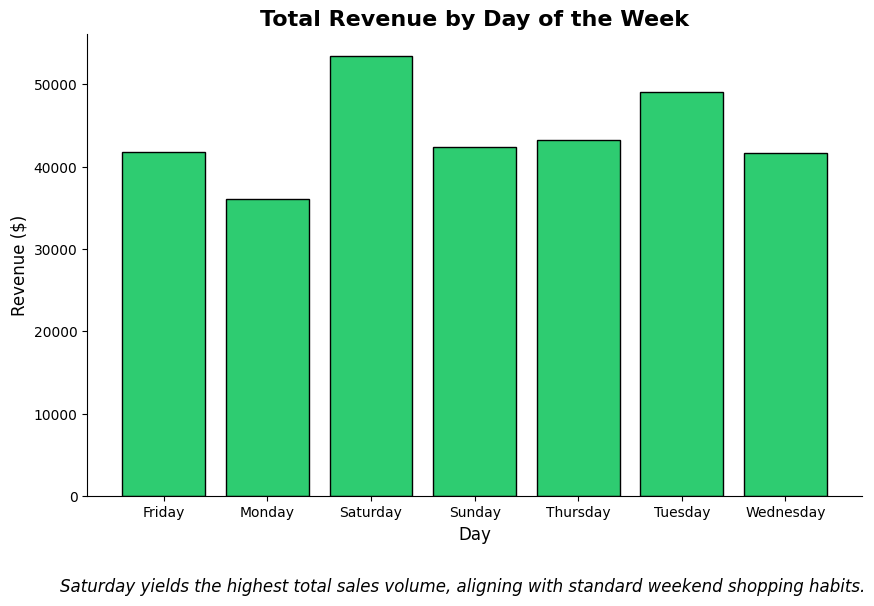

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')

ax.bar(result.index, result.values , color='#2ECC71', edgecolor='black')

plt.title('Total Revenue by Day of the Week', fontsize=16, fontweight='bold', color='black')
plt.xlabel('Day', fontsize=12, color='black')
plt.ylabel('Revenue ($)', fontsize=12, color='black')
ax.tick_params(colors='black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

insight = "Saturday yields the highest total sales volume, aligning with standard weekend shopping habits."
plt.figtext(0.5, -0.05, insight, ha="center", fontsize=12, fontstyle="italic", color="black")

plt.show()

Is there a relationship between the product line and the average customer satisfaction rating?

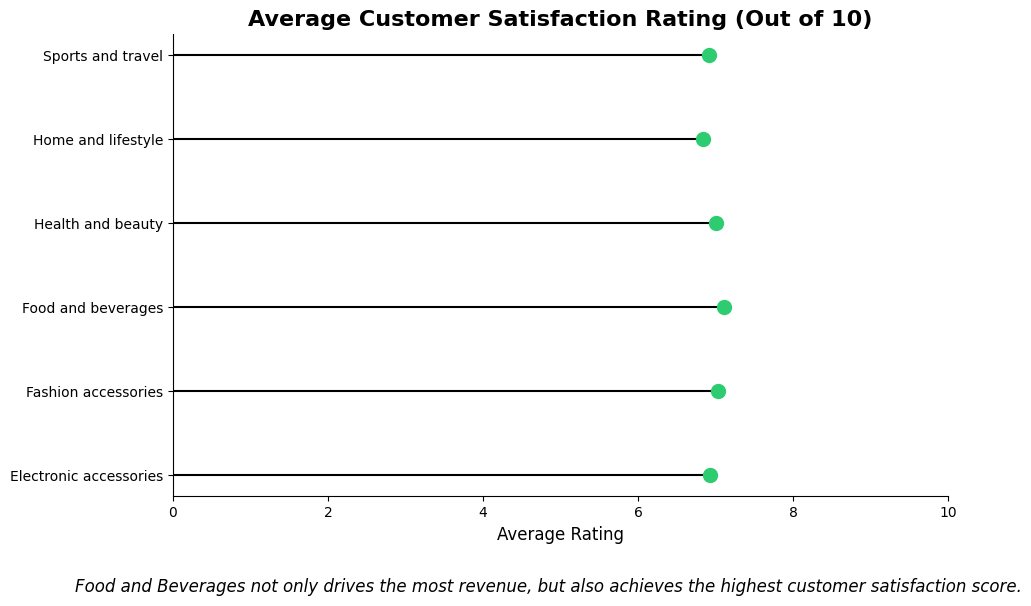

In [122]:
fig, ax = plt.subplots(figsize=(10, 6))

result=df.groupby('product_line')['rating'].mean()

ax.hlines(y=result.index, xmin=0, xmax=result.values, color='black')
ax.plot(result.values, result.index, "o", color='#2ECC71', markersize=10)

plt.title('Average Customer Satisfaction Rating (Out of 10)', fontsize=16, fontweight='bold', color='black')
plt.xlabel('Average Rating', fontsize=12, color='black')
plt.xlim(0, 10)
ax.tick_params(colors='black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

insight = "Food and Beverages not only drives the most revenue, but also achieves the highest customer satisfaction score."
plt.figtext(0.5, -0.05, insight, ha="center", fontsize=12, fontstyle="italic", color="black")

plt.show()

#### SQL

##### Setup

In [34]:
user = 'root'
password = 'Kunal'
host = 'localhost'
database = 'supermarket_db'

connection_string = f"mysql+pymysql://{user}:{password}@{host}/{database}"
engine = create_engine(connection_string)


df.to_sql('sales', con=engine, if_exists='replace', index=False)

1000

In [35]:
pd.read_sql_query(
    'select * from sales limit 5',
    con = engine
)

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5%,sales,date,time,payment,cogs,gross_margin_percentage,gross_income,rating,revenue,date_time
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,522.83,2019-01-05 13:08:00
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,76.40,2019-03-08 10:29:00
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,324.31,2019-03-03 13:23:00
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,465.76,2019-01-27 20:33:00
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,604.17,2019-02-08 10:37:00


##### Which of the three branches generated the highest total revenue, and what was their average transaction value?

In [36]:
query_1 = """
    select 
        branch, 
        sum(unit_price * quantity) as total_revenue,
        avg(unit_price * quantity) as avg_transaction
    from sales
    group by branch
    order by total_revenue DESC
"""

pd.read_sql(query_1,con=engine)

,branch,total_revenue,avg_transaction
0,Giza,105303.53,321.047348
1,Alex,101143.21,297.480029
2,Cairo,101140.64,304.640482


##### Does purchasing behavior differ by gender, and which product line is the most popular (by total quantity sold) among female customers versus male customers?


In [37]:
query_2 = """
    select 
        gender, 
        product_line, 
        sum(quantity) as total_quantity_sold
    from sales
    group by gender, product_line
    order by gender, total_quantity_sold DESC;
"""

pd.read_sql(query_2 , con=engine)

,gender,product_line,total_quantity_sold
0,Female,Sports and travel,600.0
1,Female,Fashion accessories,586.0
2,Female,Food and beverages,568.0
3,Female,Home and lifestyle,561.0
4,Female,Electronic accessories,548.0
5,Female,Health and beauty,425.0
6,Male,Health and beauty,429.0
7,Male,Electronic accessories,423.0
8,Male,Food and beverages,384.0
9,Male,Home and lifestyle,350.0


In [38]:
query_2 = '''
    WITH CTE AS (
	select product_line,gender,
	sum(quantity) as total,
    row_number() over( partition by gender order by sum(quantity) DESC ) as rnk
	from sales
    group by gender,product_line
)

select product_line,gender,total
from cte
where rnk = 1;
'''

pd.read_sql(query_2 , con=engine) 

,product_line,gender,total
0,Sports and travel,Female,600.0
1,Health and beauty,Male,429.0


What is the busiest time of day for the supermarket based on the total number of transactions and total revenue?

In [39]:
query_3 = '''
    select 
    hour(date_time) as hour,
    count(invoice_id) as total_transactions,
    sum(unit_price * quantity) AS total_revenue
from sales
group by hour
order by total_revenue DESC , total_transactions DESC
'''

pd.read_sql(query_3, con=engine)

,hour,total_transactions,total_revenue
0,19,113,37809.06
1,13,103,33069.74
2,10,101,29925.22
3,15,102,29694.77
4,14,83,29360.38
5,11,90,28930.79
6,12,89,24824.65
7,18,93,24790.80
8,16,77,24025.07
9,17,74,23281.16


Do 'Member' tier customers spend more on average than 'Normal' tier customers, and do their preferred payment methods differ?

In [40]:
query_4 = """
    select 
        customer_type,payment,
        COUNT(invoice_id) as transaction_count,
        round(avg(revenue),2) as total_spent
    from sales
    group by customer_type, payment
    order by customer_type, total_spent DESC;
"""

pd.read_sql(query_4,con=engine)

,customer_type,payment,transaction_count,total_spent
0,Member,Credit card,187,323.56
1,Member,Cash,192,319.08
2,Member,Ewallet,186,316.63
3,Normal,Cash,152,300.00
4,Normal,Ewallet,159,288.44
5,Normal,Credit card,124,286.00


Which product provided the supermarket with the most sales?

In [41]:
query_5 = """
    select 
        product_line, 
        sum(revenue) as total_revenue
    from sales
    group by product_line
    order by total_revenue DESC;
"""

pd.read_sql(query_5,con=engine)

,product_line,total_revenue
0,Food and beverages,53471.28
1,Sports and travel,52497.93
2,Electronic accessories,51750.03
3,Fashion accessories,51719.90
4,Home and lifestyle,51297.06
5,Health and beauty,46851.18


Which location of the supermarket provided the highest income?

In [42]:
query_6 = """
    select 
    city, 
    round(sum(gross_income), 2) as total_gross_income
from sales
group by city
order by total_gross_income DESC;
"""

pd.read_sql(query_6,con=engine)

,city,total_gross_income
0,Naypyitaw,5265.18
1,Yangon,5057.16
2,Mandalay,5057.03


Which day of the month, year, and week were the market sales the highest?

In [46]:
query_7 = """
    SELECT 
        DAYNAME(date_time) AS day_of_week,
        SUM(unit_price * quantity) AS total_revenue
    FROM sales
    GROUP BY day_of_week
    ORDER BY total_revenue DESC;
"""

pd.read_sql(query_7,con=engine)

,day_of_week,total_revenue
0,Saturday,53448.39
1,Tuesday,49030.71
2,Thursday,43189.76
3,Sunday,42340.85
4,Friday,41834.61
5,Wednesday,41648.70
6,Monday,36094.36


In [116]:
query_8 = """
    SELECT 
        product_line, 
        AVG(rating) AS avg_satisfaction_rating
    FROM sales
    GROUP BY product_line
    ORDER BY avg_satisfaction_rating DESC;
"""

pd.read_sql(query_8,con=engine)

,product_line,avg_satisfaction_rating
0,Food and beverages,7.113218
1,Fashion accessories,7.029213
2,Health and beauty,7.003289
3,Electronic accessories,6.924706
4,Sports and travel,6.916265
5,Home and lifestyle,6.837500
